
>>> Model K-Means dan Scaler Berhasil Disimpan di folder 'model/'! <<<

=== METRIK EVALUASI K-MEANS UNTUK JURNAL ===
Cluster K=1 -> Inertia: 5014.00 | Silhouette Score: N/A
Cluster K=2 -> Inertia: 3273.05 | Silhouette Score: 0.3879
Cluster K=3 -> Inertia: 2409.09 | Silhouette Score: 0.3857
Cluster K=4 -> Inertia: 1927.15 | Silhouette Score: 0.3815
Cluster K=5 -> Inertia: 1562.64 | Silhouette Score: 0.3673
Cluster K=6 -> Inertia: 1366.97 | Silhouette Score: 0.3635
Cluster K=7 -> Inertia: 1180.43 | Silhouette Score: 0.3682
Cluster K=8 -> Inertia: 1018.53 | Silhouette Score: 0.3756
Cluster K=9 -> Inertia: 920.63 | Silhouette Score: 0.3465


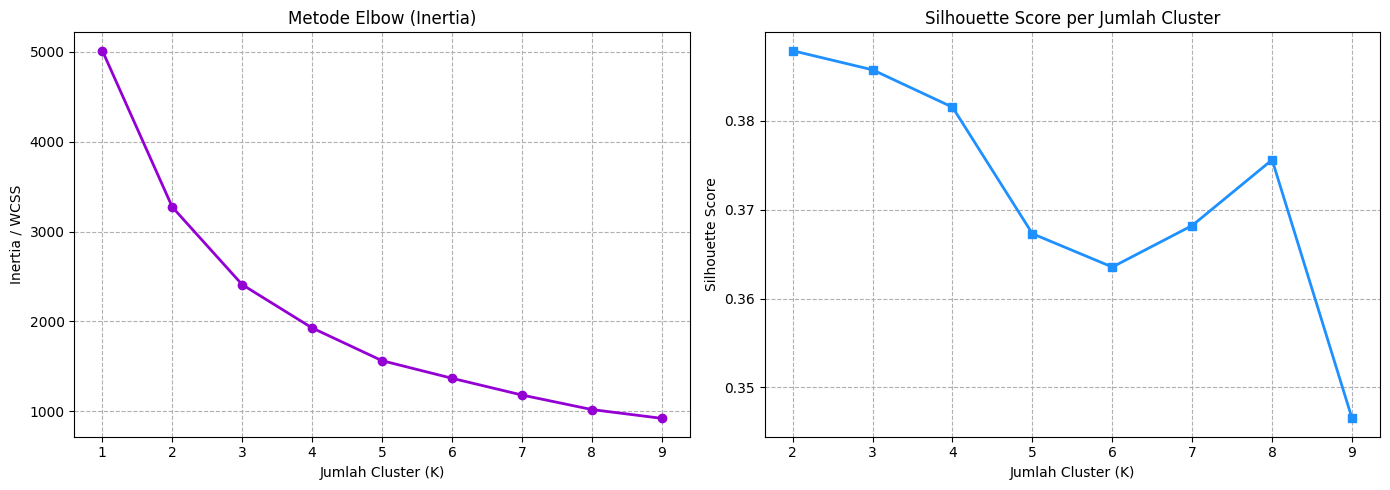

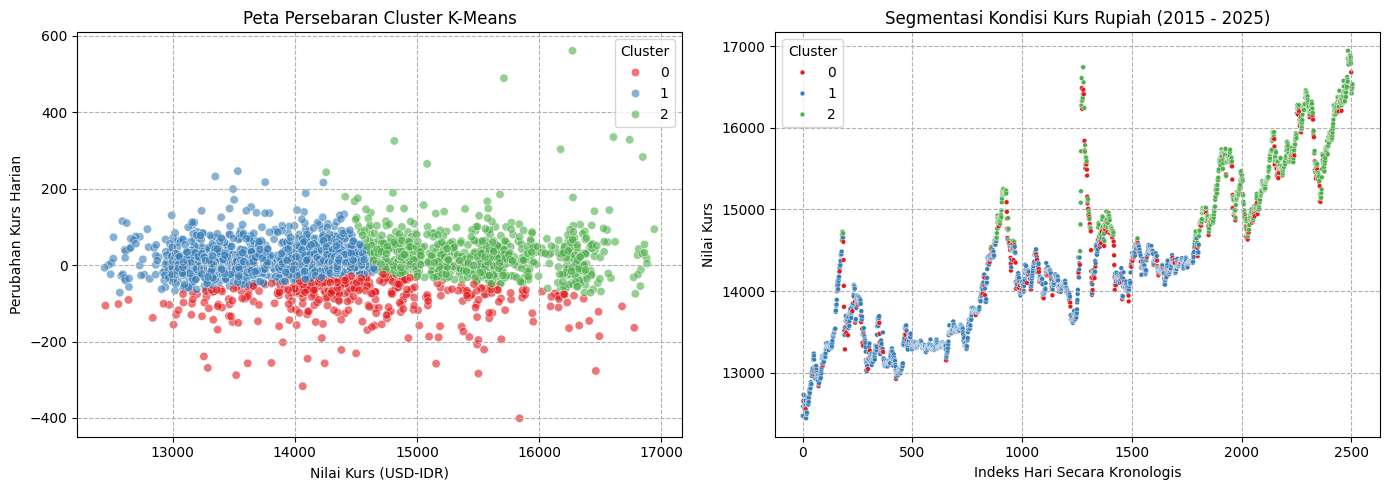

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# =====================================================================
# 1. LOAD DAN PREPROCESSING DATA
# =====================================================================
df = pd.read_csv('../data/USD-IDR.csv', sep=';')
df = df.dropna(subset=['Kurs'])
df = df.iloc[::-1].reset_index(drop=True) 
df['Kurs'] = pd.to_numeric(df['Kurs'])

# Feature Engineering
df['Selisih_Harian'] = df['Kurs'].diff().fillna(0)
features = ['Kurs', 'Selisih_Harian']
X = df[features].values

# Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================================================
# 2. EVALUASI CLUSTER (ELBOW METHOD & SILHOUETTE SCORE)
# =====================================================================
inertia = []
silhouette_scores = []
k_range = range(2, 10)

inertia_k1 = KMeans(n_clusters=1, random_state=42, n_init=10).fit(X_scaled).inertia_
inertia.append(inertia_k1)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# =====================================================================
# 3. IMPLEMENTASI K-MEANS DENGAN K OPTIMAL (Misal K=3)
# =====================================================================
K_OPTIMAL = 3
kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# =====================================================================
# 3.5. PROSES MENYIMPAN MODEL K-MEANS & SCALER (TAMBAHAN BARU)
# =====================================================================
# Mengatur folder penyimpanan ke '../model' agar sejajar dengan folder data
folder_model = '../model'
if not os.path.exists(folder_model):
    os.makedirs(folder_model)

# Menyimpan model K-Means dan Scaler menggunakan Joblib
joblib.dump(kmeans_final, os.path.join(folder_model, 'model_kmeans_kurs.joblib'))
joblib.dump(scaler, os.path.join(folder_model, 'scaler_kmeans.joblib'))
print("\n>>> Model K-Means dan Scaler Berhasil Disimpan di folder 'model/'! <<<")

# =====================================================================
# 4. PRINT METRIK EVALUASI (Untuk Tabel Jurnal)
# =====================================================================
print("\n=== METRIK EVALUASI K-MEANS UNTUK JURNAL ===")
print(f"Cluster K=1 -> Inertia: {inertia_k1:.2f} | Silhouette Score: N/A")
for i, k in enumerate(k_range):
    print(f"Cluster K={k} -> Inertia: {inertia[i+1]:.2f} | Silhouette Score: {silhouette_scores[i]:.4f}")
print("="*45)

# =====================================================================
# 5. VISUALISASI GRAFIK (ELBOW, SILHOUETTE, DAN HASIL CLUSTER)
# =====================================================================
# Menampilkan grafik evaluasi
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 10), inertia, marker='o', color='darkviolet', linewidth=2)
plt.title('Metode Elbow (Inertia)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia / WCSS')
plt.grid(True, linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', color='dodgerblue', linewidth=2)
plt.title('Silhouette Score per Jumlah Cluster')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

# Menampilkan grafik hasil clustering
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Kurs', y='Selisih_Harian', hue='Cluster', palette='Set1', alpha=0.6)
plt.title('Peta Persebaran Cluster K-Means')
plt.xlabel('Nilai Kurs (USD-IDR)')
plt.ylabel('Perubahan Kurs Harian')
plt.grid(True, linestyle='--')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x=df.index, y='Kurs', hue='Cluster', palette='Set1', s=12)
plt.title('Segmentasi Kondisi Kurs Rupiah (2015 - 2025)')
plt.xlabel('Indeks Hari Secara Kronologis')
plt.ylabel('Nilai Kurs')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()